In [1]:
import os

print(os.getcwd())
print(os.listdir())


C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset
['.ipynb_checkpoints', 'annotations_coco.json', 'COCO-conversion-script.py', 'images', 'labels', 'labels-YOLO', 'README.md', 'step3.ipynb', 'YOLO-conversion-script.py']


In [2]:
import os

label_folder = "labels-YOLO"

files = os.listdir(label_folder)
print("Total label files:", len(files))

first_file = files[0]
print("Checking:", first_file)

with open(os.path.join(label_folder, first_file), "r") as f:
    print(f.read())

Total label files: 2009
Checking: 20250216_164325.txt
2 0.466407 0.552778 0.298437 0.144444
0 0.604688 0.556944 0.043751 0.113889
0 0.285156 0.544444 0.051562 0.055555
0 0.387500 0.498611 0.053124 0.047222
1 0.421875 0.672222 0.050000 0.088889
1 0.259375 0.891666 0.203126 0.205555
1 0.368750 0.745833 0.059376 0.125000
1 0.617188 0.561111 0.074999 0.105556
1 0.506250 0.486112 0.153124 0.038889


Step 4 — Split the Dataset

In [3]:
import os
import shutil
import random

# -----------------------
# Paths
# -----------------------
base_dir = "."

images_dir = os.path.join(base_dir, "images")
labels_dir = os.path.join(base_dir, "labels-YOLO")

output_images = os.path.join(base_dir, "RoadDamage", "images")
output_labels = os.path.join(base_dir, "RoadDamage", "labels")

# -----------------------
# Create folders
# -----------------------
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_images, split), exist_ok=True)
    os.makedirs(os.path.join(output_labels, split), exist_ok=True)

# -----------------------
# Get image list
# -----------------------
images = []

for file in os.listdir(images_dir):
    if file.endswith((".jpg", ".jpeg", ".png")):
        images.append(file)

random.seed(42)
random.shuffle(images)

# -----------------------
# Split
# -----------------------
train_split = int(0.7 * len(images))
val_split = int(0.9 * len(images))

train_files = images[:train_split]
val_files = images[train_split:val_split]
test_files = images[val_split:]

splits = {
    "train": train_files,
    "val": val_files,
    "test": test_files
}

# -----------------------
# Copy files
# -----------------------
for split, files in splits.items():

    for image_file in files:

        image_src = os.path.join(images_dir, image_file)

        label_file = os.path.splitext(image_file)[0] + ".txt"
        label_src = os.path.join(labels_dir, label_file)

        shutil.copy(image_src,
                    os.path.join(output_images, split, image_file))

        if os.path.exists(label_src):
            shutil.copy(label_src,
                        os.path.join(output_labels, split, label_file))

print("Dataset Split Completed!")

print(f"Train Images : {len(train_files)}")
print(f"Validation Images : {len(val_files)}")
print(f"Test Images : {len(test_files)}")

Dataset Split Completed!
Train Images : 1406
Validation Images : 402
Test Images : 201


In [4]:
import os

print("Train Images :", len(os.listdir("RoadDamage/images/train")))
print("Val Images   :", len(os.listdir("RoadDamage/images/val")))
print("Test Images  :", len(os.listdir("RoadDamage/images/test")))

print("Train Labels :", len(os.listdir("RoadDamage/labels/train")))
print("Val Labels   :", len(os.listdir("RoadDamage/labels/val")))
print("Test Labels  :", len(os.listdir("RoadDamage/labels/test")))

Train Images : 1406
Val Images   : 402
Test Images  : 201
Train Labels : 1406
Val Labels   : 402
Test Labels  : 201


In [6]:
!pip install -U ultralytics

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 18.7 MB/s  0:00:00
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   -------- ------------------------------- 9.4/44.0 MB 46.2 MB/s eta 0:00:01
   --------------- ------------------------ 17.0/44.0 MB 41.9 MB/s eta 0:00:01
   --------------------------------- ------ 37.0/44.0 MB 59.2 MB/s eta 0:00:01
   ---------------------------------------- 44.0/44.0 MB 58.8 MB/s  0:00:00
   ---------------------------------------- 0.0/837.6 kB ? eta -:--:--
   ---------------------------------------- 837.6/837.6 kB 45.9 MB/s  0:00:00
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
   --------------- ------------------------ 19.9/52.7 MB 99.2 MB/s eta 0:00:01
   ------------------------------ --------- 40.6/52.7 MB 98.0 MB/s eta 0:00:01
   -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\SRMAP_JC203\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
from ultralytics import YOLO

print("Ultralytics installed successfully!")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\SRMAP_JC203\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics installed successfully!


In [8]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Torch Version: 2.12.1+cpu
CUDA Available: False


In [9]:
# ==========================================================
# STEP 8 : Verify Dataset Configuration
# ==========================================================

import os

print("Current Working Directory:")
print(os.getcwd())

print("\nChecking Files...")
print("dataset.yaml Exists :", os.path.exists("dataset.yaml"))
print("RoadDamage Folder Exists :", os.path.exists("RoadDamage"))

print("\nRoadDamage Folder Contents:")
print(os.listdir("RoadDamage"))

Current Working Directory:
C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset

Checking Files...
dataset.yaml Exists : True
RoadDamage Folder Exists : True

RoadDamage Folder Contents:
['images', 'labels']


In [10]:
# ==========================================================
# STEP 9 : Load the Pretrained YOLO11n Model
# ==========================================================

from ultralytics import YOLO

# Load pretrained YOLO11 Nano model
model = YOLO("yolo11n.pt")

print("YOLO11n model loaded successfully!")

YOLO11n model loaded successfully!


In [11]:
# ==========================================================
# STEP 10 : Test YOLO11n Training (5 Epochs)
# ==========================================================

results = model.train(
    data="dataset.yaml",
    epochs=5,
    imgsz=640,
    batch=8,
    device="cpu",
    workers=2,
    project="RoadDamage_Project",
    name="YOLO11n_Test",
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.90  Python-3.13.14 torch-2.12.1+cpu CPU (Intel Core Ultra 9 285)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11n_Test, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

In [12]:
# ==========================================================
# STEP 11 : Train YOLO11n Model (50 Epochs)
# ==========================================================

from ultralytics import YOLO

# Load pretrained model
model = YOLO("yolo11n.pt")

# Train the model
results = model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device="cpu",
    workers=2,
    project="RoadDamage_Project",
    name="YOLO11n_Final",
    pretrained=True,
    patience=10,
    cache=True,
    verbose=True
)

Ultralytics 8.4.90  Python-3.13.14 torch-2.12.1+cpu CPU (Intel Core Ultra 9 285)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11n_Final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspecti

In [14]:
# ==========================================================
# STEP 12 : Evaluate the Trained YOLO11n Model
# ==========================================================

from ultralytics import YOLO

# Load the best trained model
model = YOLO("RoadDamage_Project/YOLO11n_Final/weights/best.pt")

# Evaluate the model on the test dataset
metrics = model.val(
    data="dataset.yaml",
    split="test",
    imgsz=640,
    batch=8,
    device="cpu"
)

print("Model Evaluation Completed Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'RoadDamage_Project\\YOLO11n_Final\\weights\\best.pt'

In [17]:
# ==========================================================
# STEP 12 : Evaluate the Trained YOLO11n Model
# ==========================================================

from ultralytics import YOLO

# Load the best trained model
model = YOLO("runs/detect/RoadDamage_Project/YOLO11n_Final/weights/best.pt")

# Evaluate the model
metrics = model.val(
    data="dataset.yaml",
    split="test",
    imgsz=640,
    batch=8,
    device="cpu"
)

print("Model Evaluation Completed Successfully!")

Ultralytics 8.4.90  Python-3.13.14 torch-2.12.1+cpu CPU (Intel Core Ultra 9 285)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 978.5263.0 MB/s, size: 107.7 KB)
val: Scanning C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\labels\test... 201 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 201/201 3.4Kit/s 0.1s
val: New cache created: C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 7.5it/s 3.5s0.1s
                   all        201        492      0.507      0.443      0.438      0.188
               pothole         77        129      0.445      0.326      0.336      0.136
                 crack        139        271      0.424      0.328      0.328      0.119
               manhole         70         92      0.65

In [18]:
# ==========================================================
# STEP 13 : Perform Object Detection on Test Images
# ==========================================================

from ultralytics import YOLO

# Load the best trained model
model = YOLO("runs/detect/RoadDamage_Project/YOLO11n_Final/weights/best.pt")

# Perform inference on the test dataset
results = model.predict(
    source="RoadDamage/images/test",
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project="RoadDamage_Project",
    name="YOLO11n_Test_Predictions"
)

print("Object Detection Completed Successfully!")


image 1/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_164838.jpg: 384x640 2 cracks, 2 manholes, 36.5ms
image 2/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_165056.jpg: 384x640 2 potholes, 26.8ms
image 3/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_170531.jpg: 384x640 2 potholes, 22.9ms
image 4/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_170556.jpg: 384x640 2 potholes, 22.9ms
image 5/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_170909.jpg: 384x640 1 pothole, 20.1ms
image 6/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250223_104750.jpg: 384x640 9 potholes, 28.5ms
image 7/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\

In [19]:
# ==========================================================
# STEP 14 : Display Evaluation Metrics
# ==========================================================

# Print the evaluation metrics

print(f"mAP@50       : {metrics.box.map50:.4f}")
print(f"mAP@50-95    : {metrics.box.map:.4f}")
print(f"Precision    : {metrics.box.mp:.4f}")
print(f"Recall       : {metrics.box.mr:.4f}")

mAP@50       : 0.4384
mAP@50-95    : 0.1877
Precision    : 0.5068
Recall       : 0.4426


In [20]:
# ==========================================================
# STEP 15 : Perform Object Detection on Test Images
# ==========================================================

from ultralytics import YOLO

# Load the best trained model
model = YOLO("runs/detect/RoadDamage_Project/YOLO11n_Final/weights/best.pt")

# Run inference on test images
results = model.predict(
    source="RoadDamage/images/test",
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project="RoadDamage_Project",
    name="Predictions"
)

print("Object Detection Completed Successfully!")


image 1/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_164838.jpg: 384x640 2 cracks, 2 manholes, 23.4ms
image 2/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_165056.jpg: 384x640 2 potholes, 20.7ms
image 3/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_170531.jpg: 384x640 2 potholes, 24.4ms
image 4/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_170556.jpg: 384x640 2 potholes, 22.9ms
image 5/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_170909.jpg: 384x640 1 pothole, 20.8ms
image 6/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250223_104750.jpg: 384x640 9 potholes, 22.4ms
image 7/201 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\

In [23]:
# ==========================================================
# STEP 16 : Display Predicted Images
# ==========================================================

import os
import matplotlib.pyplot as plt
from PIL import Image

# Prediction folder
prediction_folder = "runs/detect/RoadDamage_Project/Predictions"

# Get all predicted images
images = [f for f in os.listdir(prediction_folder)
          if f.lower().endswith((".jpg", ".jpeg", ".png"))]

print("Total Predicted Images :", len(images))

# Display first 5 prediction images
for image_name in images[:5]:

    image_path = os.path.join(prediction_folder, image_name)

    img = Image.open(image_path)

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")
    plt.show()

Total Predicted Images : 201


<Figure size 1200x800 with 1 Axes>

<Figure size 1200x800 with 1 Axes>

<Figure size 1200x800 with 1 Axes>

<Figure size 1200x800 with 1 Axes>

<Figure size 1200x800 with 1 Axes>

In [25]:
# ==========================================================
# STEP 17.1 : View Test Images
# ==========================================================

import os

test_folder = "RoadDamage/images/test"

images = os.listdir(test_folder)

print("Total Images :", len(images))
print("\nFirst 20 Images:\n")

for img in images[:20]:
    print(img)

Total Images : 201

First 20 Images:

20250219_164838.jpg
20250219_165056.jpg
20250219_170531.jpg
20250219_170556.jpg
20250219_170909.jpg
20250223_104750.jpg
20250223_144246.jpg
20250223_144828.jpg
20250223_144853.jpg
vlcsnap-00013.jpg
vlcsnap-00029.jpg
vlcsnap-00034.jpg
vlcsnap-00041.jpg
vlcsnap-00046.jpg
vlcsnap-00061.jpg
vlcsnap-00063.jpg
vlcsnap-00078.jpg
vlcsnap-00087.jpg
vlcsnap-00090.jpg
vlcsnap-00092.jpg


In [26]:
# ==========================================================
# STEP 17 : Perform Object Detection on a Single Test Image
# ==========================================================

from ultralytics import YOLO

# Load the trained model
model = YOLO("runs/detect/RoadDamage_Project/YOLO11n_Final/weights/best.pt")

# Select a test image
image_path = "RoadDamage/images/test/20250219_164838.jpg"

# Perform prediction
results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project="RoadDamage_Project",
    name="Custom_Image_Prediction"
)

print("Prediction Completed Successfully!")


image 1/1 C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\RoadDamage\images\test\20250219_164838.jpg: 384x640 2 cracks, 2 manholes, 25.8ms
Speed: 1.1ms preprocess, 25.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\runs\detect\RoadDamage_Project\Custom_Image_Prediction
1 label saved to C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\runs\detect\RoadDamage_Project\Custom_Image_Prediction\labels
Prediction Completed Successfully!


Prediction Images:
['20250219_164838.jpg']


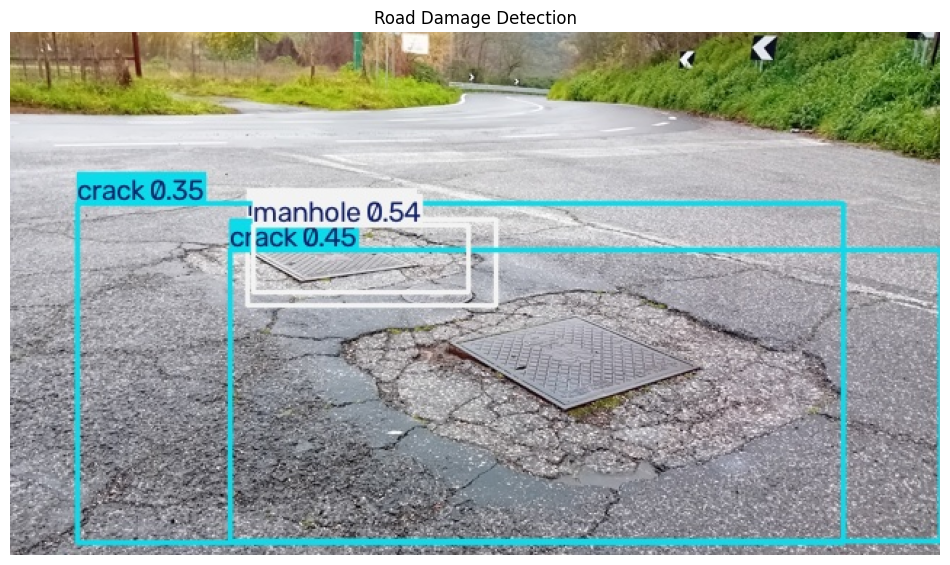

In [28]:
# ==========================================================
# STEP 18 : Display the Predicted Image
# ==========================================================

import os
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

prediction_folder = "runs/detect/RoadDamage_Project/Custom_Image_Prediction"

# Get prediction images
images = [f for f in os.listdir(prediction_folder)
          if f.lower().endswith((".jpg", ".jpeg", ".png"))]

print("Prediction Images:")
print(images)

# Display the first prediction image
img = Image.open(os.path.join(prediction_folder, images[0]))

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title("Road Damage Detection")
plt.axis("off")
plt.show()

In [29]:
# ==========================================================
# STEP 19 : Display Detection Details (Class, Confidence, Bounding Box)
# ==========================================================

from ultralytics import YOLO

# Load the trained model
model = YOLO("runs/detect/RoadDamage_Project/YOLO11n_Final/weights/best.pt")

# Image for prediction
image_path = "RoadDamage/images/test/20250219_164838.jpg"

# Perform prediction
results = model.predict(
    source=image_path,
    conf=0.25,
    verbose=False
)

# Class names
class_names = model.names

print("=" * 70)
print("DETECTION RESULTS")
print("=" * 70)

# Display each detected object
for result in results:

    if len(result.boxes) == 0:
        print("No objects detected.")

    for i, box in enumerate(result.boxes, start=1):

        cls = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        print(f"\nObject {i}")
        print("-" * 40)
        print(f"Class       : {class_names[cls]}")
        print(f"Confidence  : {conf:.4f}")
        print(f"Bounding Box: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

print("\nDetection Completed Successfully!")

DETECTION RESULTS

Object 1
----------------------------------------
Class       : manhole
Confidence  : 0.5440
Bounding Box: (167.4, 133.7, 315.1, 179.6)

Object 2
----------------------------------------
Class       : crack
Confidence  : 0.4454
Bounding Box: (151.1, 150.1, 640.0, 350.9)

Object 3
----------------------------------------
Class       : crack
Confidence  : 0.3467
Bounding Box: (46.4, 119.0, 573.7, 351.7)

Object 4
----------------------------------------
Class       : manhole
Confidence  : 0.2894
Bounding Box: (163.7, 129.2, 334.9, 188.2)

Detection Completed Successfully!


In [30]:
# ==========================================================
# STEP 20 : Count Total Detected Objects
# ==========================================================

from collections import Counter

# Count detected classes
counter = Counter()

for result in results:
    for box in result.boxes:
        cls = int(box.cls[0])
        counter[class_names[cls]] += 1

print("=" * 60)
print("ROAD DAMAGE SUMMARY")
print("=" * 60)

print(f"Potholes Detected : {counter['pothole']}")
print(f"Cracks Detected   : {counter['crack']}")
print(f"Manholes Detected : {counter['manhole']}")

print("\nTotal Objects Detected :", sum(counter.values()))

ROAD DAMAGE SUMMARY
Potholes Detected : 0
Cracks Detected   : 2
Manholes Detected : 2

Total Objects Detected : 4


In [31]:
# ==========================================================
# STEP 21 : Detect Road Damage in All Test Images
# ==========================================================

from ultralytics import YOLO
from collections import Counter

# Load trained model
model = YOLO("runs/detect/RoadDamage_Project/YOLO11n_Final/weights/best.pt")

# Test image folder
test_folder = "RoadDamage/images/test"

# Run inference on all test images
results = model.predict(
    source=test_folder,
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    project="RoadDamage_Project",
    name="All_Test_Predictions",
    verbose=False
)

# Count detections
counter = Counter()

for result in results:
    for box in result.boxes:
        cls = int(box.cls[0])
        counter[model.names[cls]] += 1

print("=" * 60)
print("ROAD DAMAGE DETECTION SUMMARY (TEST DATASET)")
print("=" * 60)

print(f"Potholes : {counter['pothole']}")
print(f"Cracks   : {counter['crack']}")
print(f"Manholes : {counter['manhole']}")
print(f"Total    : {sum(counter.values())}")

Results saved to C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\runs\detect\RoadDamage_Project\All_Test_Predictions
183 labels saved to C:\Users\SRMAP_JC203\Desktop\prateep\vizag_intern\archive\dataset\runs\detect\RoadDamage_Project\All_Test_Predictions\labels
ROAD DAMAGE DETECTION SUMMARY (TEST DATASET)
Potholes : 105
Cracks   : 221
Manholes : 96
Total    : 422
